# The training of the PN2V with PAUS data

Note that here we have the choice of constrained N2V and standard N2V.

In [1]:
import os
os.chdir('../pn2v/src/pn2v')
#os.chdir('../pn2v_ELU/src/pn2v')
from core import prediction
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
from unet import UNet
from core import utils
from core import training
from core import histNoiseModel

import dask.array as da
from dask import compute
import pandas as pd

device=utils.getDevice()

CUDA available? True


In [2]:
os.chdir('../../..')

path1 = './data saved/stamps_515.zarr'
imgs = da.from_zarr(path1)
imgs_part = imgs.compute()

/data/aai/scratch/jchan/miniconda3/envs/denoise/lib/python3.12/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


In [3]:
train_part = imgs_part[:2400]
val_part = imgs_part[2400:]

# We should use noise model here (the epoch should be larger)

In [5]:
net = UNet(800, depth=3)
path='./model saved/'
histogram=np.load(path+'PAUSnoiseModel.npy')
noiseModel=histNoiseModel.NoiseModel(histogram, device=device)

trainHist, valHist = training.trainNetwork(net=net, trainData=train_part, valData=val_part,
                                           postfix='name_the_model', directory=path, noiseModel=noiseModel,
                                           device=device, numOfEpochs= 200, stepsPerEpoch=10, 
                                           virtualBatchSize=10, batchSize=10, learningRate=6e-4,patchSize=32)

/data/aai/scratch/jchan/miniconda3/envs/denoise/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 0 finished      
avg. loss: 1.121141743659973+-(2SEM)0.20345773846913454      
Epoch 1 finished      
avg. loss: 0.45587269961833954+-(2SEM)0.1968451756876478      
Epoch 2 finished      
avg. loss: 0.4429576963186264+-(2SEM)0.08349310297979731      
Epoch 3 finished      
avg. loss: 0.4266043037176132+-(2SEM)0.10523740572193764      
Epoch 4 finished      
avg. loss: 0.43125796020030976+-(2SEM)0.048462568875315644      
Epoch 5 finished      
avg. loss: 0.31462377309799194+-(2SEM)0.05068085599360295      
Epoch 6 finished      
avg. loss: 0.33355327844619753+-(2SEM)0.08053660602873614      
Epoch 7 finished      
avg. loss: 0.2946287229657173+-(2SEM)0.06650025428985895      
Epoch 8 finished      
avg. loss: 0.2938656896352768+-(2SEM)0.05252430819005133      
Epoch 9 finished      
avg. loss: 0.26234518103301524+-(2SEM)0.08621348196300276      
Epoch 10 finished      
avg. loss: 0.26325094103813174+-(2SEM)0.05849433763371914      
Epoch 11 finished      
avg. loss: 0.25701600313

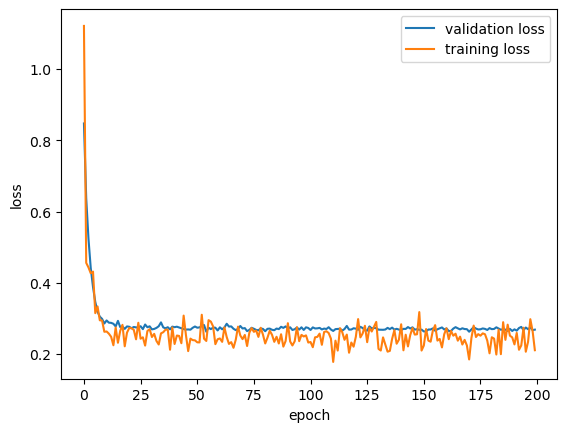

In [6]:
# Let's look at the training and validation loss
plt.xlabel('epoch')
plt.ylabel('loss')
plt.plot(valHist, label='validation loss')
plt.plot(trainHist, label='training loss')
plt.legend()
plt.show()

# Test the val set

(-0.5, 95.5, 95.5, -0.5)

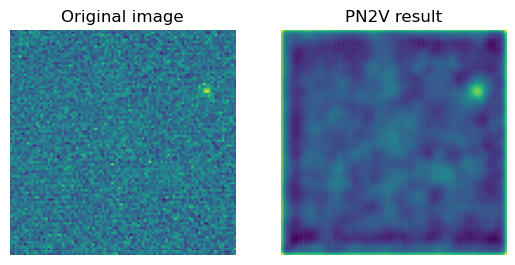

In [7]:
num = 68
n2vResult = prediction.tiledPredict(val_part[num], net ,ps=96, overlap=48,
                                            device=device, noiseModel=noiseModel)

fig, axes = plt.subplots(ncols=2)

im1 = axes[0].imshow(val_part[num])
axes[0].set_title('Original image')
axes[0].axis('off')

im2 = axes[1].imshow(n2vResult[1])
axes[1].set_title('PN2V result')
axes[1].axis('off')